In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS, Adam
from tqdm import tqdm
import scipy.io

import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(current_dir))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import *

if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = 'cuda'

In [3]:
data = scipy.io.loadmat('./cylinder_nektar_wake.mat')

In [4]:
U_star = data['U_star']
P_star = data['p_star']
t_star = data['t']
X_star = data['X_star']

N = X_star.shape[0]
T = t_star.shape[0]

XX = np.tile(X_star[:,0:1], (1,T))
YY = np.tile(X_star[:,1:2], (1,T))
TT = np.tile(t_star, (1,N)).T

UU = U_star[:,0,:]
VV = U_star[:,1,:]
PP = P_star

x = XX.flatten()[:,None]
y = YY.flatten()[:,None]
t = TT.flatten()[:,None]

u = UU.flatten()[:,None]
v = VV.flatten()[:,None]
p = PP.flatten()[:,None]

idx = np.random.choice(N*T,2500, replace=False)
x_train = x[idx,:]
y_train = y[idx,:]
t_train = t[idx,:]
u_train = u[idx,:]
v_train = v[idx,:]

x_train = torch.tensor(x_train, dtype=torch.float32, requires_grad=True).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32, requires_grad=True).to(device)
t_train = torch.tensor(t_train, dtype=torch.float32, requires_grad=True).to(device)
u_train = torch.tensor(u_train, dtype=torch.float32, requires_grad=True).to(device)
v_train = torch.tensor(v_train, dtype=torch.float32, requires_grad=True).to(device)

In [5]:
class PINNs(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, num_layer):
        super(PINNs, self).__init__()

        layers = []
        for i in range(num_layer-1):
            if i == 0:
                layers.append(nn.Linear(in_features=in_dim, out_features=hidden_dim))
                layers.append(nn.Tanh())
            else:
                layers.append(nn.Linear(in_features=hidden_dim, out_features=hidden_dim))
                layers.append(nn.Tanh())

        layers.append(nn.Linear(in_features=hidden_dim, out_features=out_dim))

        self.linear = nn.Sequential(*layers)

    def forward(self, x, y, t):
        src = torch.cat((x,y,t), dim=-1)
        return self.linear(src)

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [6]:
model = PINNs(in_dim=3, hidden_dim=512, out_dim=2, num_layer=4).to(device)
model.apply(init_weights)
optim = LBFGS(model.parameters(), line_search_fn='strong_wolfe')

n_params = get_n_params(model)

print(model)
print(get_n_params(model))

PINNs(
  (linear): Sequential(
    (0): Linear(in_features=3, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): Tanh()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): Tanh()
    (6): Linear(in_features=512, out_features=2, bias=True)
  )
)
528386


In [7]:
loss_track = []

for i in tqdm(range(1000)):
    def closure():
        psi_and_p = model(x_train, y_train, t_train)
        psi = psi_and_p[:,0:1]
        p = psi_and_p[:,1:2]

        u = torch.autograd.grad(psi, y_train, grad_outputs=torch.ones_like(psi), retain_graph=True, create_graph=True)[0]
        v = - torch.autograd.grad(psi, x_train, grad_outputs=torch.ones_like(psi), retain_graph=True, create_graph=True)[0]

        u_t = torch.autograd.grad(u, t_train, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        u_x = torch.autograd.grad(u, x_train, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        u_y = torch.autograd.grad(u, y_train, grad_outputs=torch.ones_like(u), retain_graph=True, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_train, grad_outputs=torch.ones_like(u_x), retain_graph=True, create_graph=True)[0]
        u_yy = torch.autograd.grad(u_y, y_train, grad_outputs=torch.ones_like(u_y), retain_graph=True, create_graph=True)[0]

        v_t = torch.autograd.grad(v, t_train, grad_outputs=torch.ones_like(v), retain_graph=True, create_graph=True)[0]
        v_x = torch.autograd.grad(v, x_train, grad_outputs=torch.ones_like(v), retain_graph=True, create_graph=True)[0]
        v_y = torch.autograd.grad(v, y_train, grad_outputs=torch.ones_like(v), retain_graph=True, create_graph=True)[0]
        v_xx = torch.autograd.grad(v_x, x_train, grad_outputs=torch.ones_like(v_x), retain_graph=True, create_graph=True)[0]
        v_yy = torch.autograd.grad(v_y, y_train, grad_outputs=torch.ones_like(v_y), retain_graph=True, create_graph=True)[0]

        p_x = torch.autograd.grad(p, x_train, grad_outputs=torch.ones_like(p), retain_graph=True, create_graph=True)[0]
        p_y = torch.autograd.grad(p, y_train, grad_outputs=torch.ones_like(p), retain_graph=True, create_graph=True)[0]

        f_u = u_t + (u*u_x + v*u_y) + p_x - 0.01*(u_xx + u_yy) 
        f_v = v_t + (u*v_x + v*v_y) + p_y - 0.01*(v_xx + v_yy)

        loss = torch.mean((u - u_train)**2) + torch.mean((v - v_train)**2) + torch.mean(f_u**2) + torch.mean(f_v**2)

        loss_track.append(loss.item())

        optim.zero_grad()
        loss.backward()
        return loss

    optim.step(closure)

100%|██████████| 1000/1000 [13:26<00:00,  1.24it/s]


In [8]:
np.save('./results/ns_loss_pinns.npy', loss_track)
torch.save(model.state_dict(), './results/ns_pinns.pt')

loss_track[-1]

1.905929275380913e-05

In [7]:
 # Test Data
snap = np.array([100])
x_star = X_star[:,0:1]
y_star = X_star[:,1:2]
t_star = TT[:,snap]

u_star = U_star[:,0,snap]
v_star = U_star[:,1,snap]
p_star = P_star[:,snap]

x_star = torch.tensor(x_star, dtype=torch.float32, requires_grad=True).to(device)
y_star = torch.tensor(y_star, dtype=torch.float32, requires_grad=True).to(device)
t_star = torch.tensor(t_star, dtype=torch.float32, requires_grad=True).to(device)


In [8]:
# with torch.no_grad():
psi_and_p = model(x_star, y_star, t_star)
psi = psi_and_p[:,0:1]
p_pred = psi_and_p[:,1:2]

u_pred = torch.autograd.grad(psi, x_star, grad_outputs=torch.ones_like(psi), retain_graph=True, create_graph=True)[0]
v_pred = - torch.autograd.grad(psi, y_star, grad_outputs=torch.ones_like(psi), retain_graph=True, create_graph=True)[0]

u_pred = u_pred.cpu().detach().numpy()
v_pred = v_pred.cpu().detach().numpy()
p_pred = p_pred.cpu().detach().numpy()

error_u_l2 = np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)
error_v_l2 = np.linalg.norm(v_star-v_pred,2)/np.linalg.norm(v_star,2)
error_p_l2 = np.linalg.norm(p_star-p_pred,2)/np.linalg.norm(p_star,2)

error_u_l2, error_v_l2, error_p_l2

(0.9938104076026506, 3.290545082768765, 2.5773400398489352)

In [9]:
error_u_l1 = np.linalg.norm(u_star-u_pred,1)/np.linalg.norm(u_star,1)
error_v_l1 = np.linalg.norm(v_star-v_pred,1)/np.linalg.norm(v_star,1)
error_p_l1 = np.linalg.norm(p_star-p_pred,1)/np.linalg.norm(p_star,1)

error_u_l1, error_v_l1, error_p_l1

(0.9578438697496613, 3.694744832365808, 3.7127164473010232)

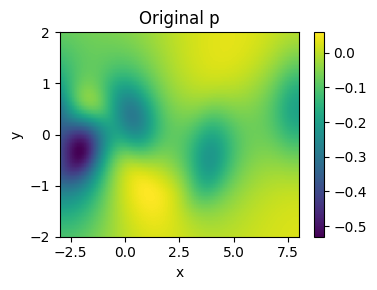

In [10]:
plt.figure(figsize=(4,3))
plt.imshow((p_star).reshape(50,100), extent=[-3,8,-2,2], aspect='auto')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original p')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/ns_exact.png')
plt.show()

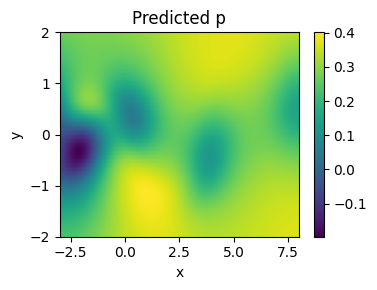

In [11]:
plt.figure(figsize=(4,3))
plt.imshow((p_pred).reshape(50,100), extent=[-3,8,-2,2], aspect='auto')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Predicted p')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/ns_pinns_pred.png')
plt.show()

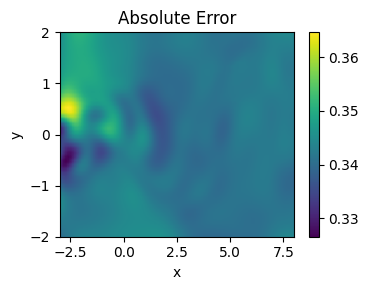

In [12]:
plt.figure(figsize=(4,3))
plt.imshow(np.abs(p_pred-p_star).reshape(50,100), extent=[-3,8,-2,2], aspect='auto')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/ns_pinns_error.png')
plt.show()